In [0]:
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

In [0]:
bookings_df = spark.read.csv(
    "dbfs:/Volumes/sathya_databrciks123/default/sathya/bookings.csv",
    header=True,
    inferSchema=True
)

flights_df = spark.read.csv(
    "dbfs:/Volumes/sathya_databrciks123/default/sathya/Flights.csv",
    header=True,
    inferSchema=True
)

bookings_df.printSchema()
flights_df.printSchema()

root
 |-- booking_id: string (nullable = true)
 |-- flight_id: string (nullable = true)
 |-- passenger_name: string (nullable = true)
 |-- travel_class: string (nullable = true)
 |-- ticket_price: integer (nullable = true)
 |-- booking_date: date (nullable = true)

root
 |-- flight_id: string (nullable = true)
 |-- airline: string (nullable = true)
 |-- from_city: string (nullable = true)
 |-- to_city: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- status: string (nullable = true)



In [0]:
revenue_airline = bookings_df.join(
    flights_df,
    "flight_id"
).groupBy("airline").agg(
    sum("ticket_price").alias("revenue")
)

display(revenue_airline)

airline,revenue
Air India,68000
Akasa,62000
Indigo,90000
Vistara,71500


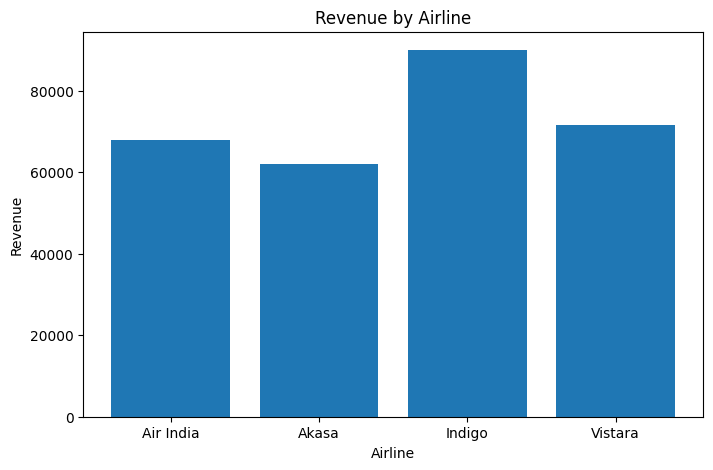

In [0]:
pdf = revenue_airline.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf["airline"], pdf["revenue"])
plt.title("Revenue by Airline")
plt.xlabel("Airline")
plt.ylabel("Revenue")
plt.show()

In [0]:
travel_class = bookings_df.groupBy(
    "travel_class"
).agg(
    sum("ticket_price").alias("revenue")
)

display(travel_class)

travel_class,revenue
Business,122000
Premium Economy,81500
Economy,88000


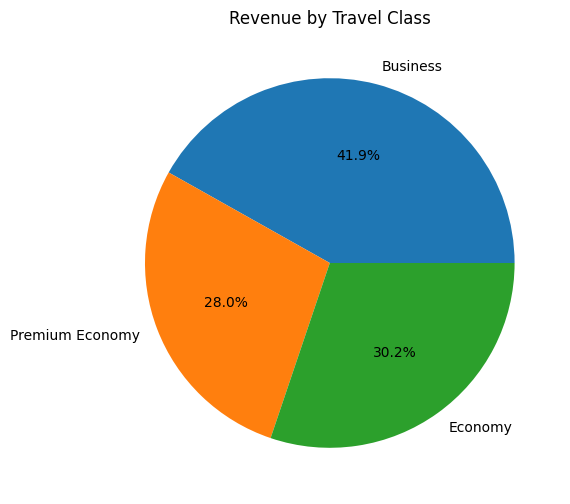

In [0]:
pdf = travel_class.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    pdf["revenue"],
    labels=pdf["travel_class"],
    autopct="%1.1f%%"
)

plt.title("Revenue by Travel Class")
plt.show()

In [0]:
status_df = flights_df.groupBy(
    "status"
).count()

display(status_df)

status,count
On Time,9
Delayed,4
Cancelled,2


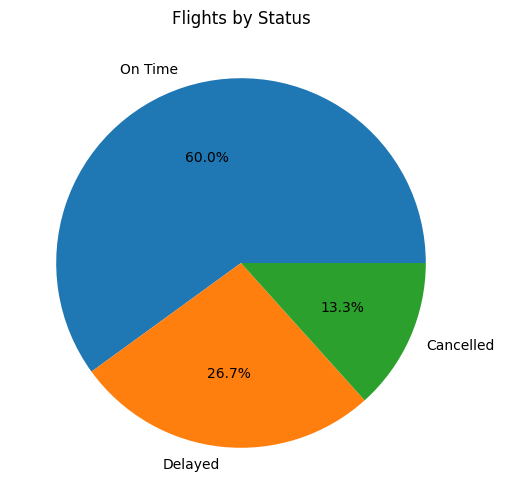

In [0]:
pdf = status_df.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    pdf["count"],
    labels=pdf["status"],
    autopct="%1.1f%%"
)

plt.title("Flights by Status")
plt.show()

In [0]:
routes_df = flights_df.withColumn(
    "route",
    concat_ws(
        " -> ",
        col("from_city"),
        col("to_city")
    )
)

top_routes = routes_df.groupBy(
    "route"
).count()

display(top_routes)

route,count
Pune -> Delhi,1
Mumbai -> Hyderabad,1
Delhi -> Hyderabad,1
Delhi -> Mumbai,1
Kolkata -> Bangalore,1
Delhi -> Chennai,1
Bangalore -> Mumbai,1
Mumbai -> Chennai,1
Hyderabad -> Delhi,1
Hyderabad -> Goa,1


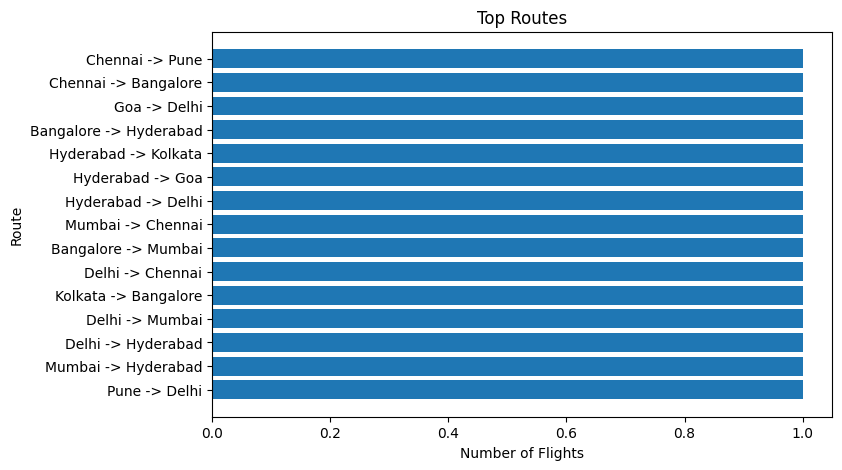

In [0]:
pdf = top_routes.toPandas()

plt.figure(figsize=(8,5))
plt.barh(
    pdf["route"],
    pdf["count"]
)

plt.title("Top Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

In [0]:
from pyspark.sql.functions import *

bookings_transformed = bookings_df.withColumn(
    "revenue",
    col("ticket_price")
).withColumn(
    "price_band",
    when(col("ticket_price") > 20000, "Premium")
    .when(col("ticket_price") > 10000, "Standard")
    .otherwise("Budget")
)

display(bookings_transformed)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date,revenue,price_band
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,8500,Budget
B1002,F101,Priya Reddy,Business,22000,2026-06-01,22000,Premium
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,9000,Budget
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,15000,Standard
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,7500,Budget
B1006,F105,Neha Singh,Business,25000,2026-06-03,25000,Premium
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,10000,Budget
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,17000,Standard
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,9500,Budget
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,28000,Premium


In [0]:
flights_transformed = flights_df.withColumn(
    "delay_flag",
    when(col("status") == "Delayed", "Yes")
    .otherwise("No")
)

display(flights_transformed)

flight_id,airline,from_city,to_city,duration,status,delay_flag
F101,Indigo,Hyderabad,Delhi,140,On Time,No
F102,Air India,Mumbai,Chennai,120,Delayed,Yes
F103,Vistara,Bangalore,Hyderabad,90,On Time,No
F104,Indigo,Delhi,Mumbai,130,Cancelled,No
F105,Air India,Chennai,Bangalore,80,On Time,No
F106,Akasa,Pune,Delhi,150,Delayed,Yes
F107,Vistara,Hyderabad,Kolkata,160,On Time,No
F108,Indigo,Mumbai,Hyderabad,110,On Time,No
F109,Akasa,Delhi,Chennai,145,Delayed,Yes
F110,Air India,Bangalore,Mumbai,95,On Time,No


In [0]:
bookings_transformed.write \
    .mode("overwrite") \
    .format("delta") \
    .saveAsTable("bookings_transformed")

flights_transformed.write \
    .mode("overwrite") \
    .format("delta") \
    .saveAsTable("flights_transformed")

In [0]:
preferences_df = spark.read.option(
    "multiline",
    "true"
).json(
    "dbfs:/Volumes/sathya_databrciks123/default/sathya/passengers.json"
)

display(preferences_df)

extra_baggage,meal,passenger_name,seat
true,Veg,Rahul Sharma,Window
false,Non-Veg,Priya Reddy,Aisle
false,Veg,Amit Kumar,Middle
true,Jain,Sneha Patel,Window
false,Non-Veg,Farhan Ali,Aisle
true,Veg,Neha Singh,Window
false,Veg,Arjun Verma,Middle
true,Jain,Meera Nair,Window
false,Veg,Kiran Rao,Aisle
true,Non-Veg,Nisha Reddy,Window


In [0]:
booking_flight_df = bookings_transformed.join(
    flights_transformed,
    "flight_id",
    "inner"
)

display(booking_flight_df)

flight_id,booking_id,passenger_name,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag
F101,B1001,Rahul Sharma,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No
F101,B1002,Priya Reddy,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No
F102,B1003,Amit Kumar,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes
F103,B1004,Sneha Patel,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No
F104,B1005,Farhan Ali,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No
F105,B1006,Neha Singh,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No
F106,B1007,Arjun Verma,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes
F107,B1008,Meera Nair,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No
F108,B1009,Kiran Rao,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No
F109,B1010,Nisha Reddy,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes


In [0]:
journey_df = booking_flight_df.join(
    preferences_df,
    "passenger_name",
    "left"
)

display(journey_df)

passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag,extra_baggage,meal,seat
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No,true,Veg,Window
Priya Reddy,F101,B1002,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No,false,Non-Veg,Aisle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes,false,Veg,Middle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No,true,Veg,Window
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes,false,Veg,Middle
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes,true,Non-Veg,Window


In [0]:
display(
    journey_df.select(
        "booking_id",
        "passenger_name",
        "flight_id",
        "airline",
        "from_city",
        "to_city",
        "travel_class",
        "ticket_price",
        "price_band",
        "meal",
        "seat",
        "extra_baggage",
        "status",
        "delay_flag"
    )
)

booking_id,passenger_name,flight_id,airline,from_city,to_city,travel_class,ticket_price,price_band,meal,seat,extra_baggage,status,delay_flag
B1001,Rahul Sharma,F101,Indigo,Hyderabad,Delhi,Economy,8500,Budget,Veg,Window,true,On Time,No
B1002,Priya Reddy,F101,Indigo,Hyderabad,Delhi,Business,22000,Premium,Non-Veg,Aisle,false,On Time,No
B1003,Amit Kumar,F102,Air India,Mumbai,Chennai,Economy,9000,Budget,Veg,Middle,false,Delayed,Yes
B1004,Sneha Patel,F103,Vistara,Bangalore,Hyderabad,Premium Economy,15000,Standard,Jain,Window,true,On Time,No
B1005,Farhan Ali,F104,Indigo,Delhi,Mumbai,Economy,7500,Budget,Non-Veg,Aisle,false,Cancelled,No
B1006,Neha Singh,F105,Air India,Chennai,Bangalore,Business,25000,Premium,Veg,Window,true,On Time,No
B1007,Arjun Verma,F106,Akasa,Pune,Delhi,Economy,10000,Budget,Veg,Middle,false,Delayed,Yes
B1008,Meera Nair,F107,Vistara,Hyderabad,Kolkata,Premium Economy,17000,Standard,Jain,Window,true,On Time,No
B1009,Kiran Rao,F108,Indigo,Mumbai,Hyderabad,Economy,9500,Budget,Veg,Aisle,false,On Time,No
B1010,Nisha Reddy,F109,Akasa,Delhi,Chennai,Business,28000,Premium,Non-Veg,Window,true,Delayed,Yes


In [0]:
journey_df.write \
.mode("overwrite") \
.format("delta") \
.saveAsTable("passenger_journey")

In [0]:
display(
    spark.table("passenger_journey")
)

passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag,extra_baggage,meal,seat
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No,true,Veg,Window
Priya Reddy,F101,B1002,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No,false,Non-Veg,Aisle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes,false,Veg,Middle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No,true,Veg,Window
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes,false,Veg,Middle
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes,true,Non-Veg,Window


In [0]:
journey_df.createOrReplaceTempView("passenger_journey")

In [0]:
%sql

SELECT airline,
       SUM(ticket_price) AS revenue
FROM passenger_journey
GROUP BY airline
ORDER BY revenue DESC;

airline,revenue
Indigo,90000
Vistara,71500
Air India,68000
Akasa,62000


In [0]:
%sql

SELECT CONCAT(from_city,' -> ',to_city) AS route,
       SUM(ticket_price) AS revenue
FROM passenger_journey
GROUP BY from_city,to_city
ORDER BY revenue DESC;

route,revenue
Hyderabad -> Delhi,39000
Bangalore -> Hyderabad,38000
Delhi -> Chennai,28000
Hyderabad -> Kolkata,26500
Chennai -> Bangalore,25000
Chennai -> Pune,24000
Bangalore -> Mumbai,23500
Delhi -> Hyderabad,18000
Hyderabad -> Goa,16000
Kolkata -> Bangalore,10500


In [0]:
%sql

SELECT ROUND(
       AVG(ticket_price),2
       ) AS average_ticket_price
FROM passenger_journey;

average_ticket_price
14575.0


In [0]:
%sql

SELECT to_city,
       COUNT(*) AS total_passengers
FROM passenger_journey
GROUP BY to_city
ORDER BY total_passengers DESC
LIMIT 1;

to_city,total_passengers
Delhi,5


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [0]:
flight_revenue = journey_df.groupBy(
    "flight_id"
).agg(
    sum("ticket_price").alias("revenue")
)

display(flight_revenue)

flight_id,revenue
F105,25000
F112,7000
F109,28000
F110,23500
F101,39000
F106,10000
F107,26500
F114,10500
F115,18000
F111,16000


In [0]:
window_spec = Window.orderBy(
    desc("revenue")
)

top_flights = flight_revenue.withColumn(
    "rank",
    rank().over(window_spec)
)

display(top_flights)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


flight_id,revenue,rank
F101,39000,1
F103,38000,2
F109,28000,3
F107,26500,4
F105,25000,5
F113,24000,6
F110,23500,7
F115,18000,8
F111,16000,9
F114,10500,10


In [0]:
display(
    top_flights.filter(
        col("rank") <= 3
    )
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


flight_id,revenue,rank
F101,39000,1
F103,38000,2
F109,28000,3


In [0]:
route_revenue = journey_df.groupBy(
    "airline",
    "from_city",
    "to_city"
).agg(
    sum("ticket_price").alias("revenue")
)

In [0]:
window_route = Window.partitionBy(
    "airline"
).orderBy(
    desc("revenue")
)

top_routes = route_revenue.withColumn(
    "route_rank",
    rank().over(window_route)
)

display(top_routes)

airline,from_city,to_city,revenue,route_rank
Air India,Chennai,Bangalore,25000,1
Air India,Bangalore,Mumbai,23500,2
Air India,Kolkata,Bangalore,10500,3
Air India,Mumbai,Chennai,9000,4
Akasa,Delhi,Chennai,28000,1
Akasa,Chennai,Pune,24000,2
Akasa,Pune,Delhi,10000,3
Indigo,Hyderabad,Delhi,39000,1
Indigo,Delhi,Hyderabad,18000,2
Indigo,Hyderabad,Goa,16000,3


In [0]:
window_running = Window.orderBy(
    "booking_date"
)

running_revenue = journey_df.withColumn(
    "running_revenue",
    sum("ticket_price").over(window_running)
)

display(running_revenue)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag,extra_baggage,meal,seat,running_revenue
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No,true,Veg,Window,30500
Priya Reddy,F101,B1002,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No,false,Non-Veg,Aisle,30500
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes,false,Veg,Middle,54500
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No,true,Jain,Window,54500
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No,false,Non-Veg,Aisle,87000
Neha Singh,F105,B1006,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No,true,Veg,Window,87000
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes,false,Veg,Middle,114000
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No,true,Jain,Window,114000
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No,false,Veg,Aisle,151500
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes,true,Non-Veg,Window,151500


In [0]:
airline_revenue = journey_df.groupBy(
    "airline"
).agg(
    sum("ticket_price").alias("total_revenue")
)

In [0]:
window_airline = Window.orderBy(
    desc("total_revenue")
)

airline_rank = airline_revenue.withColumn(
    "airline_rank",
    rank().over(window_airline)
)

display(airline_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


airline,total_revenue,airline_rank
Indigo,90000,1
Vistara,71500,2
Air India,68000,3
Akasa,62000,4


In [0]:
destination_df = journey_df.groupBy(
    "to_city"
).agg(
    sum("ticket_price").alias("revenue")
)

In [0]:
window_destination = Window.orderBy(
    desc("revenue")
)

destination_rank = destination_df.withColumn(
    "dense_rank",
    dense_rank().over(window_destination)
)

display(destination_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


to_city,revenue,dense_rank
Hyderabad,65500,1
Delhi,56000,2
Chennai,37000,3
Bangalore,35500,4
Mumbai,31000,5
Kolkata,26500,6
Pune,24000,7
Goa,16000,8


In [0]:
top_flights.write.mode("overwrite").saveAsTable("top_revenue_flights")

airline_rank.write.mode("overwrite").saveAsTable("airline_rankings")

destination_rank.write.mode("overwrite").saveAsTable("destination_rankings")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
journey_df.write \
.format("delta") \
.mode("overwrite") \
.save("/tmp/delta/passenger_journey")

In [0]:
delta_df = spark.read.format("delta") \
.load("/tmp/delta/passenger_journey")

display(delta_df)

passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag,extra_baggage,meal,seat
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No,true,Veg,Window
Priya Reddy,F101,B1002,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No,false,Non-Veg,Aisle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes,false,Veg,Middle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No,true,Veg,Window
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes,false,Veg,Middle
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes,true,Non-Veg,Window


In [0]:
journey_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("passenger_journey_delta")

In [0]:
%sql

SELECT *
FROM passenger_journey_delta
LIMIT 10;

passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag,extra_baggage,meal,seat
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No,true,Veg,Window
Priya Reddy,F101,B1002,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No,false,Non-Veg,Aisle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes,false,Veg,Middle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No,true,Veg,Window
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes,false,Veg,Middle
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes,true,Non-Veg,Window


In [0]:
%sql
CREATE OR REPLACE TABLE flight_master
USING DELTA
AS
SELECT *
FROM flights_transformed;

num_affected_rows,num_inserted_rows


In [0]:
%sql

SELECT *
FROM flight_master;

flight_id,airline,from_city,to_city,duration,status,delay_flag
F101,Indigo,Hyderabad,Delhi,140,On Time,No
F102,Air India,Mumbai,Chennai,120,Delayed,Yes
F103,Vistara,Bangalore,Hyderabad,90,On Time,No
F104,Indigo,Delhi,Mumbai,130,Cancelled,No
F105,Air India,Chennai,Bangalore,80,On Time,No
F106,Akasa,Pune,Delhi,150,Delayed,Yes
F107,Vistara,Hyderabad,Kolkata,160,On Time,No
F108,Indigo,Mumbai,Hyderabad,110,On Time,No
F109,Akasa,Delhi,Chennai,145,Delayed,Yes
F110,Air India,Bangalore,Mumbai,95,On Time,No


In [0]:
bookings_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("booking_master")

In [0]:
incremental_data = [
("B1011","F101","New Passenger","Economy",9500,"2026-06-05"),
("B1012","F102","Test User","Business",25000,"2026-06-05")
]

columns = [
"booking_id",
"flight_id",
"passenger_name",
"travel_class",
"ticket_price",
"booking_date"
]

incremental_df = spark.createDataFrame(
    incremental_data,
    columns
)

display(incremental_df)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1011,F101,New Passenger,Economy,9500,2026-06-05
B1012,F102,Test User,Business,25000,2026-06-05


In [0]:
incremental_df.createOrReplaceTempView(
    "booking_updates"
)

In [0]:
%sql

MERGE INTO booking_master bm
USING booking_updates bu
ON bm.booking_id = bu.booking_id

WHEN MATCHED THEN
UPDATE SET *

WHEN NOT MATCHED THEN
INSERT *

num_affected_rows,num_updated_rows,num_deleted_rows,num_inserted_rows
2,2,0,0


In [0]:
%sql

SELECT *
FROM booking_master
ORDER BY booking_id;

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
%sql

DESCRIBE HISTORY booking_master;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
1,2026-06-19T09:58:50.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(booking_id#18297 = booking_id#18284)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(1696953871311088),19b2f473-c608-4274-8df7-bede9e252a00,0619-090621-1ies4pd-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 2, numTargetBytesAdded -> 3632, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 2, executionTimeMs -> 4596, materializeSourceTimeMs -> 173, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 2427, numTargetRowsUpdated -> 2, numOutputRows -> 2, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 2, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1892)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-19T09:57:53.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1696953871311088),19aee49f-6a7b-42f7-8add-3105ee6ff0b7,0619-090621-1ies4pd-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 20, numOutputBytes -> 2444)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql

SELECT *
FROM booking_master VERSION AS OF 0;

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
%sql

SELECT *
FROM booking_master VERSION AS OF 1;

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
%sql

SELECT *
FROM booking_master;

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
%sql
OPTIMIZE booking_master;

path,metrics
abfss://unity-catalog-storage@dbstoragextnwbdlpxk7zy.dfs.core.windows.net/7405608388886026/__unitystorage/catalogs/51fef89c-5ccd-4f9b-9e6d-1b0054a5bcf2/tables/9b19b692-da94-42d8-ac61-d2bbe83646f9,"List(1, 3, List(2452, 2452, 2452.0, 1, 2452), List(1809, 2444, 2025.3333333333333, 3, 6076), 0, null, null, 0, 1, 3, 0, true, 0, 0, 1781863302731, 1781863304690, 8, 1, null, List(1, 2), null, 6, 6, 393, 0, null, null)"


In [0]:
%sql
OPTIMIZE booking_master
ZORDER BY (flight_id);

path,metrics
abfss://unity-catalog-storage@dbstoragextnwbdlpxk7zy.dfs.core.windows.net/7405608388886026/__unitystorage/catalogs/51fef89c-5ccd-4f9b-9e6d-1b0054a5bcf2/tables/9b19b692-da94-42d8-ac61-d2bbe83646f9,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 2452), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1781863316945, 1781863317499, 8, 0, null, List(0, 0), null, 6, 6, 0, 0, null, null)"


In [0]:
%sql
DESCRIBE HISTORY booking_master;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-19T10:01:44.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,OPTIMIZE,"Map(predicate -> [], auto -> false, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(1696953871311088),d624507e-fcbb-4788-aa98-7326ba6dd61a,0619-090621-1ies4pd-v2n,1,SnapshotIsolation,false,"Map(numRemovedFiles -> 3, numRemovedBytes -> 6076, p25FileSize -> 2452, numDeletionVectorsRemoved -> 1, minFileSize -> 2452, numAddedFiles -> 1, maxFileSize -> 2452, p75FileSize -> 2452, p50FileSize -> 2452, numAddedBytes -> 2452)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-19T09:58:50.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(booking_id#18297 = booking_id#18284)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(1696953871311088),19b2f473-c608-4274-8df7-bede9e252a00,0619-090621-1ies4pd-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 2, numTargetBytesAdded -> 3632, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 2, executionTimeMs -> 4596, materializeSourceTimeMs -> 173, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 2427, numTargetRowsUpdated -> 2, numOutputRows -> 2, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 2, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1892)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-19T09:57:53.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1696953871311088),19aee49f-6a7b-42f7-8add-3105ee6ff0b7,0619-090621-1ies4pd-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 20, numOutputBytes -> 2444)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql
VACUUM booking_master RETAIN 168 HOURS;

path
abfss://unity-catalog-storage@dbstoragextnwbdlpxk7zy.dfs.core.windows.net/7405608388886026/__unitystorage/catalogs/51fef89c-5ccd-4f9b-9e6d-1b0054a5bcf2/tables/9b19b692-da94-42d8-ac61-d2bbe83646f9


In [0]:
journey_df.write \
.mode("overwrite") \
.format("delta") \
.saveAsTable("managed_passenger_journey")

In [0]:
%sql

SELECT *
FROM managed_passenger_journey
LIMIT 10;

passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag,extra_baggage,meal,seat
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No,true,Veg,Window
Priya Reddy,F101,B1002,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No,false,Non-Veg,Aisle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes,false,Veg,Middle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No,true,Veg,Window
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes,false,Veg,Middle
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes,true,Non-Veg,Window


In [0]:
journey_df.write \
.mode("overwrite") \
.format("delta") \
.saveAsTable("external_passenger_journey")

In [0]:
%sql
SELECT *
FROM external_passenger_journey
LIMIT 10;

passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag,extra_baggage,meal,seat
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No,true,Veg,Window
Priya Reddy,F101,B1002,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No,false,Non-Veg,Aisle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes,false,Veg,Middle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No,true,Veg,Window
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes,false,Veg,Middle
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes,true,Non-Veg,Window


In [0]:
journey_df.createOrReplaceTempView(
    "temp_passenger_journey"
)

In [0]:
journey_df.createOrReplaceTempView(
    "temp_passenger_journey"
)